# Factorization machine for rating prediction

A **factorization machine** (FM) predicts the star rating (1–5) of a (user, recipe) pair and is trained with **mean squared error**.
Every interaction becomes one feature vector `x`, which concatenates:

| block | columns | value |
|---|---|---|
| user | one-hot `user:<id>` | 1 |
| recipe | one-hot `item:<id>` | 1 |
| nutrients | a subset of the nutrition columns | `log1p`, then standardized |
| price | `price` | `log1p` of the known price sum, min-max normalized to [0, 1] |
| ingredients | multi-hot `ingr:<name>` | 1 / (number of ingredients in the recipe) |
| *(dense section only)* | `emb_1 … emb_d` | the two-tower item embedding, standardized per dimension |

The FM scores a vector as

$$\hat y(x) = w_0 + \sum_i w_i x_i + \sum_{i<j} \langle v_i, v_j\rangle x_i x_j,$$

where the pairwise term is computed in $O(kn)$ as $\tfrac12\sum_f\big[(\sum_i v_{if}x_i)^2 - \sum_i v_{if}^2x_i^2\big]$.

**Data and split** (the same as `model_training_twotowers.ipynb`, so neither model sees the other's test rows)

- Interactions come from the saved two-tower artifacts (`model_artifacts/two_tower/observed_ratings.csv`, `catalog.csv`, `two_tower.pt`).
- The split is rebuilt with the two-tower's `k_core_filter` and `per_user_split`, then checked against the saved user vocabulary.
- Only star ratings (1–5) are labels; reviews without stars (rating 0) are dropped *after* the split, so the split stays identical.
- **train**: two-tower training rows minus each user's last one. **valid**: that last one (early stopping). **test**: the two-tower's held-out rows (each user's last 2), used only for the final report.

Section A trains the **sparse** FM. Section B adds the **dense** item embedding.

In [1]:
# Run once if these packages are missing, then restart the notebook kernel.
# %pip install torch numpy pandas scipy scikit-learn joblib matplotlib
import ast
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
from IPython.display import display
from torch import nn

In [2]:
RANDOM_STATE = 42
NOTEBOOK_DIR = next((p for p in (Path.cwd(), Path.cwd() / "DataMappingRecommendation")
                     if (p / "model_training_twotowers.ipynb").is_file()), None)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Run from DataMappingRecommendation or its project root.")
TWO_TOWER_NOTEBOOK = NOTEBOOK_DIR / "model_training_twotowers.ipynb"
TWO_TOWER_DIR = NOTEBOOK_DIR / "model_artifacts/two_tower"
FM_DIR = NOTEBOOK_DIR / "model_artifacts/fm"
RAW_RECIPES_PATH = NOTEBOOK_DIR / "input/RecipeInteraction/RAW_recipes.csv"  # ingredient names only
PP_RECIPES_PATH = NOTEBOOK_DIR / "input/RecipeInteraction/PP_recipes.csv"

# Nutrient subset (the input CSV's column names). Saturated fat is left out: it tracks total fat closely.
NUTRIENT_FEATURES = ["calories (g)", "total fat (g)", "sugar (g)", "sodium (g)", "protein (g)", "carbohydrates (g)"]
PRICE_COLUMN = "price_total_known"

FM_FACTORS = 16          # k: size of each feature's latent vector v_i
BATCH_SIZE = 4096
LEARNING_RATE = 5e-3
# Ridge over *all* parameters, divided by the number of training rows: a feature seen n times is shrunk
# roughly by n / (n + lambda), so rare users and recipes stay near 0 (like the bias baseline's pseudo-ratings).
# Picked on valid MSE: lambda_v from 100 to 1000 gives the same result; per-batch L2 barely regularized.
L2_LINEAR = 10.0
L2_FACTORS = 100.0
EPOCHS = 40
EARLY_STOPPING_PATIENCE = 3
RATING_MIN, RATING_MAX = 1.0, 5.0

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}; two-tower artifacts: {TWO_TOWER_DIR}")

Device: mps; two-tower artifacts: /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/two_tower


In [3]:
# Reuse the two-tower notebook's split helpers (k_core_filter, per_user_split, build_user_lookup) rather than copying them.
two_tower_notebook = json.loads(TWO_TOWER_NOTEBOOK.read_text())
tagged = [cell for cell in two_tower_notebook["cells"] if "two-tower-core" in cell.get("metadata", {}).get("tags", [])]
if len(tagged) != 1:
    raise RuntimeError(f"Expected one cell tagged 'two-tower-core' in {TWO_TOWER_NOTEBOOK.name}.")
exec(compile("".join(tagged[0]["source"]), f"{TWO_TOWER_NOTEBOOK.name}:two-tower-core", "exec"), globals())
print(f"Loaded the two-tower-core cell from {TWO_TOWER_NOTEBOOK.name}")

Loaded the two-tower-core cell from model_training_twotowers.ipynb


## Data: the two-tower split, star ratings only

In [4]:
two_tower_config = json.loads((TWO_TOWER_DIR / "config.json").read_text())
catalog = pd.read_csv(TWO_TOWER_DIR / "catalog.csv", dtype={"recipe_id": "string"})
observed_ratings = pd.read_csv(TWO_TOWER_DIR / "observed_ratings.csv", dtype={"user_id": "string"})
observed_ratings["date"] = pd.to_datetime(observed_ratings["date"], utc=True)
vocabulary = pd.read_csv(TWO_TOWER_DIR / "user_vocabulary.csv", dtype={"user_id": "string"})

two_tower_train, two_tower_heldout = per_user_split(
    k_core_filter(observed_ratings, two_tower_config["k_core"]), two_tower_config["holdout_per_user"])
if build_user_lookup(two_tower_train) != dict(zip(vocabulary["user_id"], vocabulary["user_index"].astype(int))):
    raise RuntimeError("The rebuilt split does not reproduce the two-tower user vocabulary.")

# Labels are star ratings; rating 0 (a review without stars) has no rating to predict.
rated_train = two_tower_train[two_tower_train["rating"] > 0].reset_index(drop=True)
fm_train, fm_valid = per_user_split(rated_train, 1)
fm_test = two_tower_heldout[two_tower_heldout["rating"] > 0].reset_index(drop=True)
splits = {"train": fm_train, "valid": fm_valid, "test": fm_test}

split_summary = pd.DataFrame({
    name: {"rows": len(frame), "users": frame["user_id"].nunique(), "recipes": frame["item_index"].nunique(),
           "mean_rating": frame["rating"].mean(),
           **{f"share_{r}": frame["rating"].eq(r).mean() for r in range(1, 6)}}
    for name, frame in splits.items()}).T
display(split_summary.round(3))

,rows,users,recipes,mean_rating,share_1,share_2,share_3,share_4,share_5
train,491282.0,17784.0,41236.0,4.729,0.004,0.009,0.032,0.164,0.791
valid,17711.0,17711.0,10088.0,4.715,0.009,0.013,0.037,0.136,0.804
test,33553.0,17636.0,15004.0,4.734,0.010,0.014,0.030,0.125,0.821


## Item features: nutrients, price, ingredients

These come from the recipe catalog only (no ratings), so they are computed over every catalog recipe.

- **Nutrients:** median-imputed, `log1p` (every column is right-skewed), then standardized.
- **Price:** `log1p(price_total_known)`, then min-max normalized to [0, 1].
- **Ingredients:** the ingredient ids that `two_tower.pt` stores per recipe (`item_ingredients`, id + 1 with 0 as padding).
  Each recipe's row is multi-hot and divided by its ingredient count, so it sums to 1 (3 ingredients → 0.33 each).
  Column names come from `RAW_recipes.csv`: each id takes the raw ingredient string it is most often aligned with.

In [5]:
def ingredient_names(raw_recipes_path, pp_recipes_path):
    # id -> most frequent raw ingredient string aligned with it (the same alignment load_recipe_metadata uses).
    raw = pd.read_csv(raw_recipes_path, usecols=["id", "ingredients"])
    pp = pd.read_csv(pp_recipes_path, usecols=["id", "ingredient_ids"])
    pp_ids = dict(zip(pp["id"], pp["ingredient_ids"].map(json.loads)))
    votes = {}
    for recipe, names in zip(raw["id"], raw["ingredients"].map(ast.literal_eval)):
        ids = pp_ids.get(recipe)
        if ids is not None and len(ids) == len(names):
            for name, ingredient in zip(names, ids):
                counts = votes.setdefault(ingredient, {})
                counts[name] = counts.get(name, 0) + 1
    return {ingredient: max(counts, key=counts.get) for ingredient, counts in votes.items()}


checkpoint = torch.load(TWO_TOWER_DIR / "two_tower.pt", map_location="cpu", weights_only=False)
item_ingredients = checkpoint["state_dict"]["item_ingredients"].numpy()   # [recipes, max ingredients], id + 1, 0 pads
num_ingredients = int(checkpoint["model_config"]["num_ingredients"])
id_to_name = ingredient_names(RAW_RECIPES_PATH, PP_RECIPES_PATH)
ingredient_columns = [f"ingr:{id_to_name.get(i, f'id_{i}')}" for i in range(num_ingredients)]

# Multi-hot / n: one CSR row per catalog recipe.
rows, cols = np.nonzero(item_ingredients)
pairs = np.unique(np.c_[rows, item_ingredients[rows, cols] - 1], axis=0)   # a repeated id counts once
counts = np.bincount(pairs[:, 0], minlength=len(catalog))
item_ingredient_matrix = sp.csr_matrix(
    (1.0 / counts[pairs[:, 0]], (pairs[:, 0], pairs[:, 1])), shape=(len(catalog), num_ingredients), dtype=np.float32)

nutrients = np.log1p(catalog[NUTRIENT_FEATURES].fillna(catalog[NUTRIENT_FEATURES].median()).clip(lower=0))
nutrient_mean, nutrient_std = nutrients.mean(), nutrients.std(ddof=0)
item_nutrients = ((nutrients - nutrient_mean) / nutrient_std).to_numpy(np.float32)

log_price = np.log1p(catalog[PRICE_COLUMN].fillna(0).clip(lower=0))
price_min, price_max = float(log_price.min()), float(log_price.max())
item_price = ((log_price - price_min) / (price_max - price_min)).to_numpy(np.float32)[:, None]

content_preprocessing = {
    "nutrient_features": NUTRIENT_FEATURES, "nutrient_median": catalog[NUTRIENT_FEATURES].median(),
    "nutrient_mean": nutrient_mean, "nutrient_std": nutrient_std,
    "price_column": PRICE_COLUMN, "log_price_min": price_min, "log_price_max": price_max,
}
print(f"{num_ingredients:,} ingredients; {(counts > 0).mean():.1%} of recipes have at least one "
      f"(median {np.median(counts[counts > 0]):.0f}); nutrient block {item_nutrients.shape}, price block {item_price.shape}")

8,023 ingredients; 100.0% of recipes have at least one (median 9); nutrient block (231637, 6), price block (231637, 1)


## Feature vectors

`FeatureBuilder` turns interaction rows into a CSR matrix with one row per interaction, plus the matching column names.
The user and recipe vocabularies come from the **train** split only. A user or recipe that never appears in train
gets no ID column, so the FM scores it from content alone.

In [6]:
class FeatureBuilder:
    # Concatenates the feature blocks of each (user, recipe) row into one sparse vector.

    def __init__(self, train_rows, item_blocks):
        # item_blocks: list of (name, [recipes, d] dense array or CSR matrix, column names), indexed by item_index.
        self.users = {u: i for i, u in enumerate(sorted(train_rows["user_id"].unique()))}
        self.items = {int(r): i for i, r in enumerate(sorted(train_rows["item_index"].unique()))}
        self.item_blocks = item_blocks
        self.columns = ([f"user:{u}" for u in self.users]
                        + [f"item:{catalog['recipe_id'].iat[r]}" for r in self.items]
                        + [c for _, _, names in item_blocks for c in names])
        self.block_sizes = {"user": len(self.users), "item": len(self.items),
                            **{name: len(names) for name, _, names in item_blocks}}

    def one_hot(self, keys, lookup):
        index = np.array([lookup.get(k, -1) for k in keys])
        known = index >= 0
        return sp.csr_matrix((np.ones(known.sum(), np.float32), (np.flatnonzero(known), index[known])),
                             shape=(len(keys), len(lookup)))

    def transform(self, rows):
        items = rows["item_index"].to_numpy()
        blocks = [self.one_hot(rows["user_id"].to_numpy(), self.users),
                  self.one_hot(items.tolist(), self.items)]
        for _, block, _ in self.item_blocks:
            blocks.append(block[items] if sp.issparse(block) else sp.csr_matrix(block[items]))
        X = sp.hstack(blocks, format="csr", dtype=np.float32)
        X.eliminate_zeros()
        return X, rows["rating"].to_numpy(np.float32)


def show_row(X, columns, y, row=0, max_columns=14):
    # The nonzero columns of one feature vector, like a single row of the full matrix.
    start, end = X.indptr[row], X.indptr[row + 1]
    shown = dict(zip([columns[i] for i in X.indices[start:end]], X.data[start:end].round(3)))
    if len(shown) > max_columns:
        keys = list(shown)
        shown = {**{k: shown[k] for k in keys[:max_columns - 1]}, "…": f"+{len(keys) - max_columns + 1} more",
                 keys[-1]: shown[keys[-1]]}
    display(pd.DataFrame([{**shown, "→ y": y[row]}]))

## Factorization machine

Each row is sent to the model as a padded list of `(feature index, value)` pairs taken from its CSR row.
Padding uses an extra feature index whose weights are fixed at zero, so it adds nothing.
L2 regularization is a ridge penalty on every `w_i` and `v_i`, scaled by 1 / (train rows). A feature seen n times is
shrunk by about n / (n + λ). Penalizing only the features active in each batch did the opposite: frequent features got the
most shrinkage and the FM overfit rare users and recipes within 2 epochs.
`w0` starts at the train mean rating. Predictions are clipped to [1, 5] when evaluated.

In [7]:
class FactorizationMachine(nn.Module):
    def __init__(self, num_features, factors, global_mean=0.0):
        super().__init__()
        self.pad = num_features
        self.bias = nn.Parameter(torch.tensor([global_mean], dtype=torch.float32))
        self.linear = nn.Embedding(num_features + 1, 1, padding_idx=self.pad)
        self.factors = nn.Embedding(num_features + 1, factors, padding_idx=self.pad)
        nn.init.zeros_(self.linear.weight)
        nn.init.normal_(self.factors.weight, std=0.01)
        with torch.no_grad():
            self.factors.weight[self.pad].zero_()

    def forward(self, index, value):
        w, v = self.linear(index).squeeze(-1), self.factors(index)        # [B, L], [B, L, k]
        xv = v * value.unsqueeze(-1)
        pairwise = 0.5 * (xv.sum(1).pow(2) - xv.pow(2).sum(1)).sum(1)      # sum_{i<j} <v_i, v_j> x_i x_j
        return self.bias + (w * value).sum(1) + pairwise, w, v


def padded_batch(X, pad):
    # CSR rows -> [B, max nnz] index and value tensors; empty slots point at the zero pad feature.
    counts = np.diff(X.indptr)
    width = max(int(counts.max()), 1)
    index = np.full((X.shape[0], width), pad, dtype=np.int64)
    value = np.zeros((X.shape[0], width), dtype=np.float32)
    row = np.repeat(np.arange(X.shape[0]), counts)
    slot = np.arange(X.nnz) - np.repeat(X.indptr[:-1], counts)
    index[row, slot], value[row, slot] = X.indices, X.data
    return torch.from_numpy(index), torch.from_numpy(value)


@torch.no_grad()
def predict(model, X, batch_size=BATCH_SIZE * 4):
    model.eval()
    out = []
    for start in range(0, X.shape[0], batch_size):
        index, value = padded_batch(X[start:start + batch_size], model.pad)
        out.append(model(index.to(device), value.to(device))[0].cpu())
    return torch.cat(out).numpy().clip(RATING_MIN, RATING_MAX)


def regression_metrics(y, pred):
    error = pred - y
    return {"mse": float(np.mean(error ** 2)), "rmse": float(np.sqrt(np.mean(error ** 2))),
            "mae": float(np.mean(np.abs(error)))}


def train_fm(X_train, y_train, X_valid, y_valid, name):
    torch.manual_seed(RANDOM_STATE)
    model = FactorizationMachine(X_train.shape[1], FM_FACTORS, float(y_train.mean())).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    rng = np.random.default_rng(RANDOM_STATE)
    y_train_t = torch.from_numpy(y_train)
    history, best, best_state, stale = [], np.inf, None, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        started, total, seen = time.time(), 0.0, 0
        for batch in np.array_split(rng.permutation(X_train.shape[0]), max(1, X_train.shape[0] // BATCH_SIZE)):
            index, value = padded_batch(X_train[batch], model.pad)
            index, value, target = index.to(device), value.to(device), y_train_t[batch].to(device)
            pred, _, _ = model(index, value)
            mse = nn.functional.mse_loss(pred, target)
            ridge = L2_LINEAR * model.linear.weight.pow(2).sum() + L2_FACTORS * model.factors.weight.pow(2).sum()
            loss = mse + ridge / X_train.shape[0]
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total += mse.item() * len(batch)
            seen += len(batch)
        valid = regression_metrics(y_valid, predict(model, X_valid))
        history.append({"model": name, "epoch": epoch, "train_mse": total / seen, "valid_mse": valid["mse"],
                        "valid_rmse": valid["rmse"], "seconds": time.time() - started})
        print(f"[{name}] epoch {epoch:2d}  train MSE {total / seen:.4f}  valid MSE {valid['mse']:.4f}  "
              f"({time.time() - started:.0f}s)")
        if valid["mse"] < best - 1e-5:
            best, stale = valid["mse"], 0
            best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
        else:
            stale += 1
            if stale >= EARLY_STOPPING_PATIENCE:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

### Baselines

- **global mean:** every prediction is the train mean rating.
- **bias:** `mean + b_user + b_item`, with item then user deviations shrunk toward 0 (10 pseudo-ratings).
  An FM without its pairwise term and content features reduces to this model, so the FM should beat it.

In [8]:
def bias_baseline(train, rows, shrink=10.0):
    mu = train["rating"].mean()
    item = train.groupby("item_index")["rating"].agg(lambda r: (r - mu).sum() / (len(r) + shrink))
    residual = train["rating"] - mu - train["item_index"].map(item)
    user = residual.groupby(train["user_id"]).agg(lambda r: r.sum() / (len(r) + shrink))
    pred = mu + rows["item_index"].map(item).fillna(0) + rows["user_id"].map(user).fillna(0)
    return pred.to_numpy().clip(RATING_MIN, RATING_MAX)


results = {}
for split in ("valid", "test"):
    y = splits[split]["rating"].to_numpy(np.float32)
    results[("global mean", split)] = regression_metrics(y, np.full_like(y, fm_train["rating"].mean()))
    results[("bias", split)] = regression_metrics(y, bias_baseline(fm_train, splits[split]))
display(pd.DataFrame(results).T.round(4))

,,mse,rmse,mae
global mean,valid,0.4630,0.6804,0.4505
bias,valid,0.4168,0.6456,0.4096
global mean,test,0.4544,0.6741,0.4398
bias,test,0.4179,0.6464,0.4024


# A. Sparse FM

The feature vector is **user one-hot + recipe one-hot + nutrients + price + ingredient multi-hot / n**.

In [9]:
sparse_blocks = [
    ("nutrients", item_nutrients, [f"nutr:{c}" for c in NUTRIENT_FEATURES]),
    ("price", item_price, ["price"]),
    ("ingredients", item_ingredient_matrix, ingredient_columns),
]
sparse_builder = FeatureBuilder(fm_train, sparse_blocks)
sparse_data = {name: sparse_builder.transform(frame) for name, frame in splits.items()}
X_train, y_train = sparse_data["train"]
print(f"Sparse feature vectors: {X_train.shape[0]:,} rows x {X_train.shape[1]:,} columns, "
      f"{X_train.nnz / X_train.shape[0]:.1f} nonzeros per row")
display(pd.Series(sparse_builder.block_sizes, name="columns").to_frame().T)
show_row(X_train, sparse_builder.columns, y_train)

Sparse feature vectors: 491,282 rows x 67,050 columns, 17.7 nonzeros per row


,user,item,nutrients,price,ingredients
columns,17784,41236,6,1,8023


,user:1000107,item:108908,nutr:calories (g),nutr:total fat (g),nutr:sugar (g),nutr:sodium (g),nutr:protein (g),nutr:carbohydrates (g),price,ingr:bean sprouts,ingr:canola oil,ingr:celery,ingr:cornstarch,…,ingr:whole chicken breasts,→ y
0,1.0,1.0,-0.399,-0.409,0.447,0.714,0.402,0.226,0.575,0.077,0.077,0.077,0.077,+9 more,0.077,5.0


In [10]:
sparse_fm, sparse_history = train_fm(*sparse_data["train"], *sparse_data["valid"], "sparse FM")
for split in ("valid", "test"):
    results[("sparse FM", split)] = regression_metrics(sparse_data[split][1], predict(sparse_fm, sparse_data[split][0]))
display(pd.DataFrame(results).T.round(4))

[sparse FM] epoch  1  train MSE 0.3269  valid MSE 0.4296  (3s)
[sparse FM] epoch  2  train MSE 0.3001  valid MSE 0.4249  (2s)
[sparse FM] epoch  3  train MSE 0.2915  valid MSE 0.4211  (2s)
[sparse FM] epoch  4  train MSE 0.2864  valid MSE 0.4191  (2s)
[sparse FM] epoch  5  train MSE 0.2833  valid MSE 0.4174  (2s)
[sparse FM] epoch  6  train MSE 0.2815  valid MSE 0.4176  (2s)
[sparse FM] epoch  7  train MSE 0.2803  valid MSE 0.4169  (2s)
[sparse FM] epoch  8  train MSE 0.2794  valid MSE 0.4164  (2s)
[sparse FM] epoch  9  train MSE 0.2788  valid MSE 0.4161  (2s)
[sparse FM] epoch 10  train MSE 0.2783  valid MSE 0.4160  (2s)
[sparse FM] epoch 11  train MSE 0.2780  valid MSE 0.4162  (2s)
[sparse FM] epoch 12  train MSE 0.2778  valid MSE 0.4155  (2s)
[sparse FM] epoch 13  train MSE 0.2775  valid MSE 0.4156  (2s)
[sparse FM] epoch 14  train MSE 0.2774  valid MSE 0.4156  (2s)
[sparse FM] epoch 15  train MSE 0.2772  valid MSE 0.4154  (2s)
[sparse FM] epoch 16  train MSE 0.2772  valid MSE 0.415

mse    rmse     mae
global mean valid  0.4630  0.6804  0.4505
bias        valid  0.4168  0.6456  0.4096
global mean test   0.4544  0.6741  0.4398
bias        test   0.4179  0.6464  0.4024
sparse FM   valid  0.4147  0.6439  0.4113
            test   0.4165  0.6454  0.4047

# B. Dense FM: adding the two-tower item embedding

The embedding model is the two-tower item tower. Its output size is read from the saved config
(`model_config.embedding_dim`) and checked against `item_vectors.npy`. Each dimension becomes one column `emb_1 … emb_d`,
standardized over the catalog, so every row carries `d` dense values.
These columns are **appended** to the sparse vector from section A.

The two-tower trained on the FM's train and valid rows, but never on its test rows (its own held-out set), so the test numbers stay clean.
Early stopping on valid can be slightly optimistic, because the embedding has already seen those rows.

In [11]:
embedding_dim = int(two_tower_config["model_config"]["embedding_dim"])
item_vectors = np.load(TWO_TOWER_DIR / "item_vectors.npy", allow_pickle=False)
if item_vectors.shape != (len(catalog), embedding_dim):
    raise RuntimeError(f"item_vectors.npy is {item_vectors.shape}; expected ({len(catalog)}, {embedding_dim}).")
embedding_mean, embedding_std = item_vectors.mean(0), item_vectors.std(0) + 1e-8
item_embedding = ((item_vectors - embedding_mean) / embedding_std).astype(np.float32)
print(f"Embedding model output: {embedding_dim} dimensions per recipe "
      f"(L2 norm {np.linalg.norm(item_vectors, axis=1).mean():.3f} before standardizing)")

dense_blocks = sparse_blocks + [("embedding", item_embedding, [f"emb_{i + 1}" for i in range(embedding_dim)])]
dense_builder = FeatureBuilder(fm_train, dense_blocks)
dense_data = {name: dense_builder.transform(frame) for name, frame in splits.items()}
X_train_dense, y_train_dense = dense_data["train"]
print(f"Dense feature vectors: {X_train_dense.shape[0]:,} rows x {X_train_dense.shape[1]:,} columns, "
      f"{X_train_dense.nnz / X_train_dense.shape[0]:.1f} nonzeros per row")
# The user, recipe and embedding columns of one row (the image's layout); the full row also holds nutrients, price and ingredients.
start, end = X_train_dense.indptr[0], X_train_dense.indptr[1]
row = dict(zip([dense_builder.columns[i] for i in X_train_dense.indices[start:end]], X_train_dense.data[start:end].round(2)))
display(pd.DataFrame([{**{k: v for k, v in row.items() if k.startswith(("user:", "item:"))},
                       **{f"emb_{i}": row.get(f"emb_{i}", 0.0) for i in (1, 2)}, "…": "…",
                       f"emb_{embedding_dim}": row.get(f"emb_{embedding_dim}", 0.0), "→ y": y_train_dense[0]}]))

Embedding model output: 64 dimensions per recipe (L2 norm 1.000 before standardizing)
Dense feature vectors: 491,282 rows x 67,114 columns, 81.7 nonzeros per row


,user:1000107,item:108908,emb_1,emb_2,…,emb_64,→ y
0,1.0,1.0,-1.28,-2.11,…,1.44,5.0


In [12]:
dense_fm, dense_history = train_fm(*dense_data["train"], *dense_data["valid"], "dense FM")
for split in ("valid", "test"):
    results[("dense FM", split)] = regression_metrics(dense_data[split][1], predict(dense_fm, dense_data[split][0]))

[dense FM] epoch  1  train MSE 0.3322  valid MSE 0.4337  (4s)
[dense FM] epoch  2  train MSE 0.3016  valid MSE 0.4259  (3s)
[dense FM] epoch  3  train MSE 0.2922  valid MSE 0.4226  (3s)
[dense FM] epoch  4  train MSE 0.2877  valid MSE 0.4200  (3s)
[dense FM] epoch  5  train MSE 0.2852  valid MSE 0.4189  (3s)
[dense FM] epoch  6  train MSE 0.2833  valid MSE 0.4188  (3s)
[dense FM] epoch  7  train MSE 0.2824  valid MSE 0.4185  (3s)
[dense FM] epoch  8  train MSE 0.2817  valid MSE 0.4176  (3s)
[dense FM] epoch  9  train MSE 0.2810  valid MSE 0.4169  (3s)
[dense FM] epoch 10  train MSE 0.2804  valid MSE 0.4184  (3s)
[dense FM] epoch 11  train MSE 0.2805  valid MSE 0.4169  (3s)
[dense FM] epoch 12  train MSE 0.2800  valid MSE 0.4173  (3s)


## Comparison

MSE on the held-out **test** rows decides between the models; valid was used for early stopping.
The right-hand plot shows the mean prediction per true rating on test. The rating distribution is heavily skewed to 5★
(see the split table), so every model is pulled toward the mean, and the low ratings are where they differ most.

split          test                   valid                
                mae     mse    rmse     mae     mse    rmse
model                                                      
bias         0.4024  0.4179  0.6464  0.4096  0.4168  0.6456
dense FM     0.4149  0.4192  0.6474  0.4209  0.4169  0.6457
global mean  0.4398  0.4544  0.6741  0.4505  0.4630  0.6804
sparse FM    0.4047  0.4165  0.6454  0.4113  0.4147  0.6439

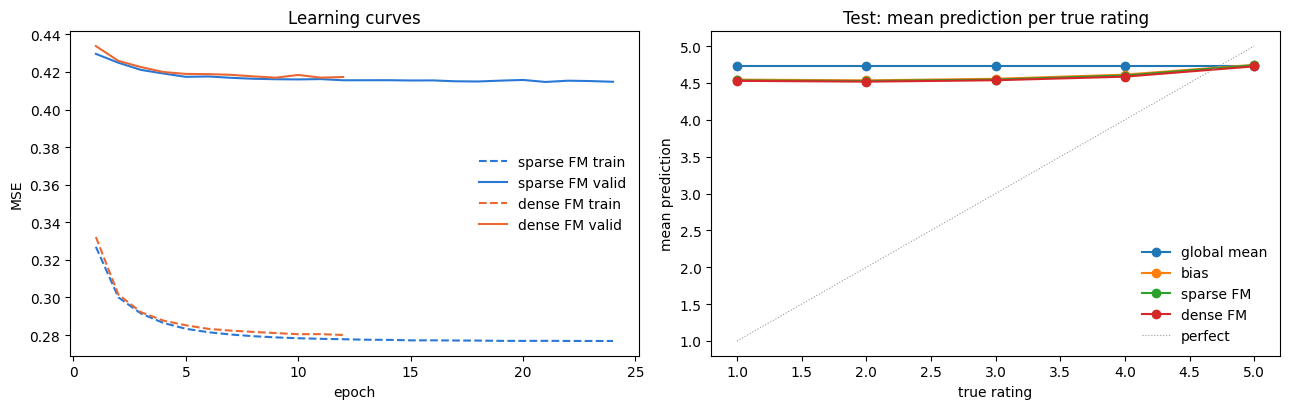

,global mean,bias,sparse FM,dense FM
true rating,,,,
1,13.904,12.634,12.560,12.509
2,7.447,6.490,6.447,6.395
3,2.989,2.478,2.447,2.415
4,0.531,0.418,0.404,0.384
5,0.074,0.096,0.099,0.108


In [13]:
report = pd.DataFrame(results).T.rename_axis(["model", "split"])
display(report.round(4).unstack("split").swaplevel(axis=1).sort_index(axis=1))

test_y = splits["test"]["rating"].to_numpy()
test_predictions = {
    "global mean": np.full(len(test_y), fm_train["rating"].mean()),
    "bias": bias_baseline(fm_train, splits["test"]),
    "sparse FM": predict(sparse_fm, sparse_data["test"][0]),
    "dense FM": predict(dense_fm, dense_data["test"][0]),
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for history, color in ((sparse_history, "#2a78d6"), (dense_history, "#eb6834")):
    name = history["model"].iat[0]
    axes[0].plot(history["epoch"], history["train_mse"], color=color, ls="--", label=f"{name} train")
    axes[0].plot(history["epoch"], history["valid_mse"], color=color, label=f"{name} valid")
axes[0].set(xlabel="epoch", ylabel="MSE", title="Learning curves")
axes[0].legend(frameon=False)
by_rating = pd.DataFrame({name: pd.Series(pred).groupby(test_y).mean() for name, pred in test_predictions.items()})
by_rating.plot(ax=axes[1], marker="o")
axes[1].plot([1, 5], [1, 5], color="0.6", lw=0.8, ls=":", label="perfect")
axes[1].set(xlabel="true rating", ylabel="mean prediction", title="Test: mean prediction per true rating")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()
display(pd.DataFrame({name: pd.Series((pred - test_y) ** 2).groupby(test_y).mean()
                      for name, pred in test_predictions.items()}).rename_axis("true rating").round(3))

## Save both models

`model_artifacts/fm/` holds each FM's weights with its feature column names and the user and recipe vocabularies, plus the
content preprocessing (nutrient imputation and scaling, price range, embedding standardization).
To score a new (user, recipe) pair, rebuild its vector with the same blocks and column order.

In [14]:
FM_DIR.mkdir(parents=True, exist_ok=True)
for name, model, builder in (("sparse", sparse_fm, sparse_builder), ("dense", dense_fm, dense_builder)):
    torch.save({"state_dict": {k: t.cpu() for k, t in model.state_dict().items()},
                "num_features": model.pad, "factors": FM_FACTORS,
                "columns": builder.columns, "block_sizes": builder.block_sizes,
                "user_vocabulary": builder.users, "item_vocabulary": builder.items,
                "rating_range": (RATING_MIN, RATING_MAX)}, FM_DIR / f"fm_{name}.pt")
joblib.dump({**content_preprocessing, "embedding_dim": embedding_dim,
             "embedding_mean": embedding_mean, "embedding_std": embedding_std}, FM_DIR / "content_preprocessing.joblib")
report.to_csv(FM_DIR / "metrics.csv")
(FM_DIR / "config.json").write_text(json.dumps({
    "task": "rating regression (MSE)", "labels": "star ratings 1-5", "split": "two-tower per_user_split; train minus last per user / last per user / two-tower held-out",
    "k_core": two_tower_config["k_core"], "holdout_per_user": two_tower_config["holdout_per_user"],
    "factors": FM_FACTORS, "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
    "l2_linear": L2_LINEAR, "l2_factors": L2_FACTORS, "nutrient_features": NUTRIENT_FEATURES,
    "embedding_source": "model_artifacts/two_tower/item_vectors.npy", "embedding_dim": embedding_dim,
    "two_tower_sha256": __import__("hashlib").sha256((TWO_TOWER_DIR / "two_tower.pt").read_bytes()).hexdigest(),
}, indent=2))
print(f"Saved to {FM_DIR}: {sorted(p.name for p in FM_DIR.iterdir())}")

Saved to /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/fm: ['config.json', 'content_preprocessing.joblib', 'fm_dense.pt', 'fm_sparse.pt', 'metrics.csv']
